# Microbiome x Metabolome cross-omics association

How are the microbiome and metabolome coupled, and which microbial taxa show strong
associations with specific metabolites?

This notebook combines two complementary views on the **1,042 patients that have a
complete row in both modalities**:

1. **Mutual information** (Section 1) - captures any (incl. non-linear) dependency between a
   taxon and a metabolite, but is *unsigned*.
2. **Spearman correlation** (Section 2) - adds *direction* (+/-) and *significance* (BH-FDR),
   which is what lets us name specific taxon <-> metabolite associations.

The microbiome table is compositional (rows sum to 1) so it is CLR-transformed first; the
serum metabolome is non-compositional and used as-is (standardized only where a method needs it).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr, false_discovery_control

In [2]:
def clr_transform(df, pseudocount=None):
    """Centered log-ratio (CLR) transform for compositional data.

    The microbiome table holds relative abundances (each row sums to 1), so it is
    compositional and must be moved to a log-ratio space before standard analyses.
    Zeros are replaced with a small pseudocount (default: half the smallest observed
    non-zero value) before taking logs.
    """
    X = df.to_numpy(dtype=float)
    if pseudocount is None:
        pseudocount = X[X > 0].min() / 2.0
    X = np.where(X <= 0, pseudocount, X)
    log_X = np.log(X)
    clr = log_X - log_X.mean(axis=1, keepdims=True)
    return pd.DataFrame(clr, index=df.index, columns=df.columns)


# Load both datasets, using the SampleID (first column) as the index
micro = pd.read_csv("train/microbiome.csv").rename(
    columns={"Unnamed: 0": "SampleID"}).set_index("SampleID")
metab = pd.read_csv("train/metabolome.csv").rename(
    columns={"Unnamed: 0": "SampleID"}).set_index("SampleID")

# Drop samples whose row is completely empty so analyses use real data only
micro = micro.dropna(how="all")
metab = metab.dropna(how="all")

# Keep only the intersection of SampleIDs present (with data) in both datasets
common_ids = micro.index.intersection(metab.index)
micro = micro.loc[common_ids].sort_index()
metab = metab.loc[common_ids].sort_index()
print(f"Samples shared by both datasets: {len(common_ids)}")
print(f"Microbiome taxa: {micro.shape[1]} | Metabolome features: {metab.shape[1]}")

# Prevalence filter on the microbiome (safeguard against near-empty taxa)
prevalence = (micro > 0).mean(axis=0)
taxa_keep = prevalence[prevalence >= 0.10].index
micro = micro[taxa_keep]
print(f"Taxa retained at >=10% prevalence: {len(taxa_keep)} / {len(prevalence)}")

# Microbiome: compositional -> CLR. Metabolome: left in raw units.
micro_clr = clr_transform(micro)
micro_scaled = pd.DataFrame(
    StandardScaler().fit_transform(micro_clr), index=micro.index, columns=micro.columns)
metab_scaled = pd.DataFrame(
    StandardScaler().fit_transform(metab), index=metab.index, columns=metab.columns)

Samples shared by both datasets: 1042
Microbiome taxa: 170 | Metabolome features: 102
Taxa retained at >=10% prevalence: 170 / 170


## 1. Mutual information: Microbiome vs Metabolome

Unsigned dependency between every taxon and every metabolite. Bright cells flag taxa /
metabolites that carry shared information; the full 170 x 102 grid is dense, so we read it
as a texture and rank the specific pairs in Section 2.

MI matrix shape: (170, 102)


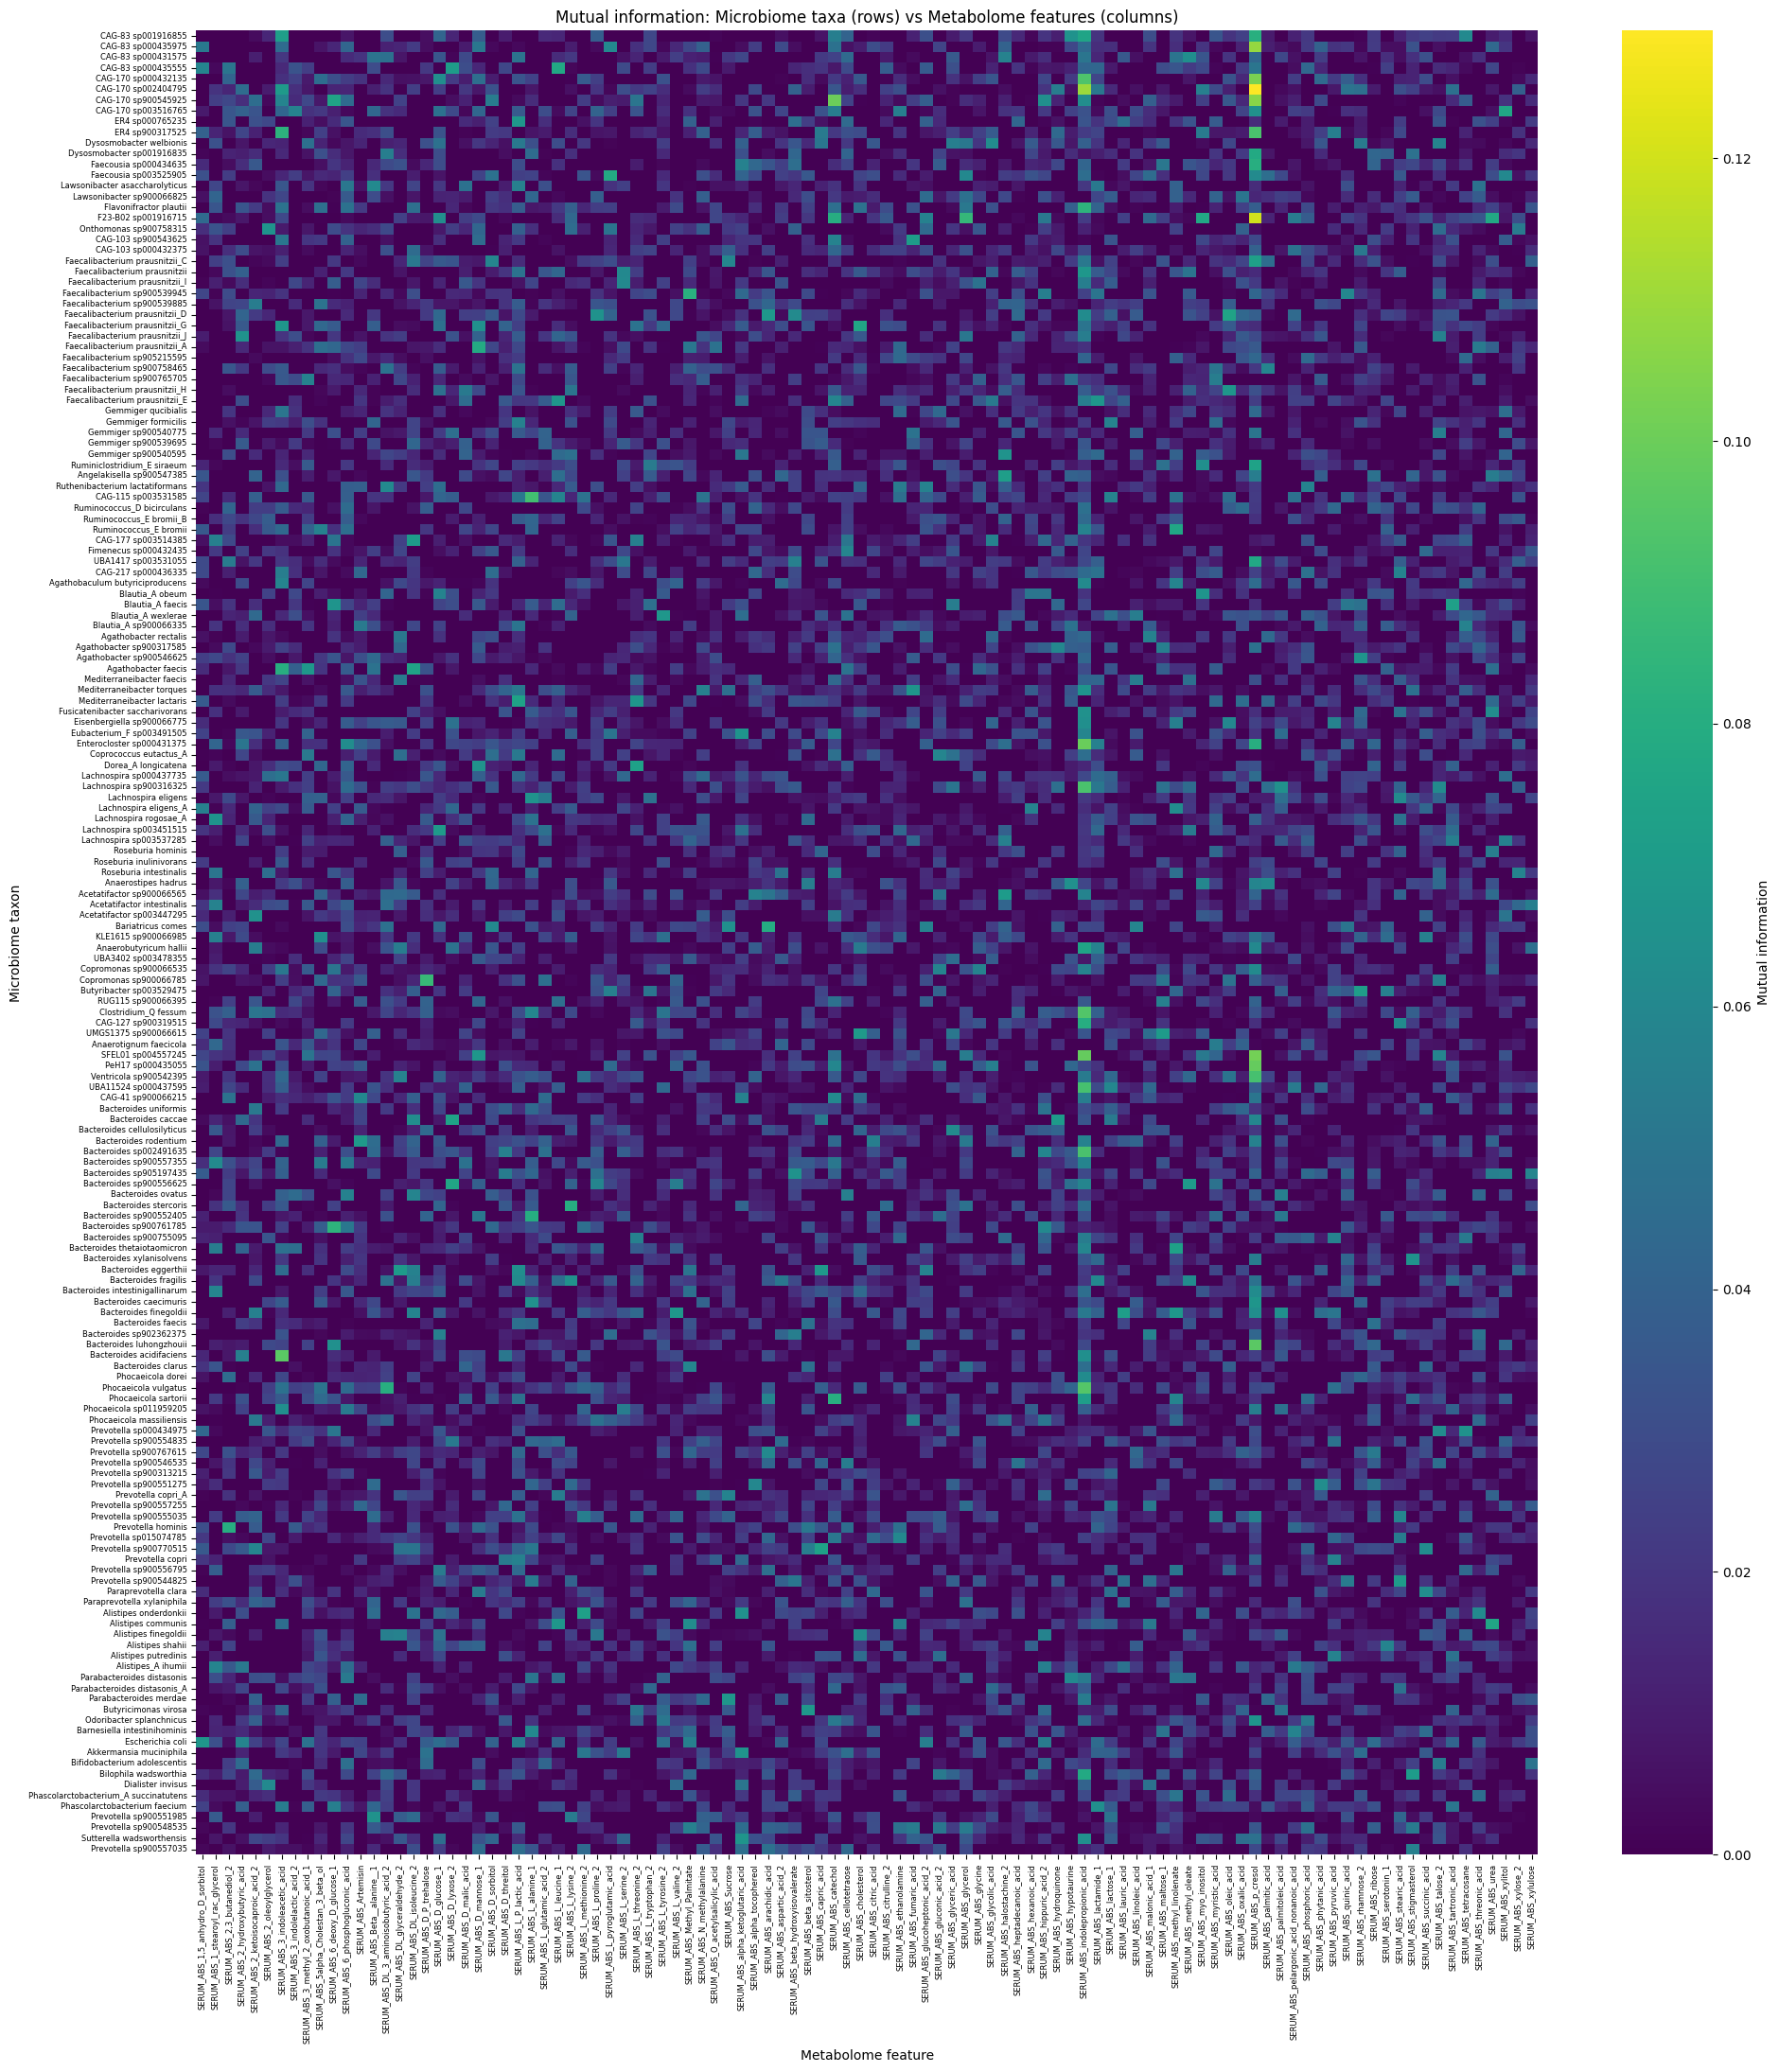

In [3]:
# Mutual information matrix (rows = microbiome taxa, columns = metabolome features)
mi_matrix = pd.DataFrame(index=micro_scaled.columns, columns=metab_scaled.columns,
                         dtype=float)

for taxon in micro_scaled.columns:
    # mutual_info_regression(X, y): metabolome as X, the taxon as the target y.
    mi_matrix.loc[taxon] = mutual_info_regression(
        metab_scaled.values, micro_scaled[taxon].values, random_state=0)

print("MI matrix shape:", mi_matrix.shape)

fig, ax = plt.subplots(figsize=(20, 22))
sns.heatmap(
    mi_matrix.astype(float),
    cmap="viridis",
    cbar_kws={"label": "Mutual information"},
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)
ax.set_title("Mutual information: Microbiome taxa (rows) vs Metabolome features (columns)")
ax.set_xlabel("Metabolome feature")
ax.set_ylabel("Microbiome taxon")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

## 2. Signed associations: Spearman correlation

Mutual information tells us *that* a taxon and a metabolite share information, but not the
*direction*. Spearman's rho on CLR(microbiome) vs raw metabolome adds sign (+/-) and a
p-value, which we Benjamini-Hochberg correct across all 170 x 102 pairs. This is the table
we draw the specific associations from.

In [4]:
# Spearman across the stacked [taxa | metabolites] matrix, then slice the cross quadrant.
R, P = spearmanr(micro_clr.values, metab.values)
n_taxa = micro_clr.shape[1]
rho = pd.DataFrame(R[:n_taxa, n_taxa:], index=micro_clr.columns, columns=metab.columns)
pval = pd.DataFrame(P[:n_taxa, n_taxa:], index=micro_clr.columns, columns=metab.columns)

# Long (tidy) table: one row per taxon-metabolite pair, with BH-FDR across all pairs.
assoc = rho.stack().rename("rho").to_frame()
assoc["p"] = pval.stack()
assoc["fdr"] = false_discovery_control(assoc["p"].to_numpy())
assoc["abs_rho"] = assoc["rho"].abs()
assoc.index = assoc.index.set_names(["taxon", "metabolite"])
print("Total taxon-metabolite pairs:", len(assoc))
assoc.head()

Total taxon-metabolite pairs: 17340


rho         p  \
taxon              metabolite                                              
CAG-83 sp001916855 SERUM_ABS_1,5_anhydro_D_sorbitol   0.023839  0.442070   
                   SERUM_ABS_1_stearoyl_rac_glycerol  0.005968  0.847421   
                   SERUM_ABS_2,3_butanediol_2         0.080861  0.009019   
                   SERUM_ABS_2_hydroxybutyric_acid   -0.142692  0.000004   
                   SERUM_ABS_2_ketoisocaproic_acid_2 -0.054760  0.077253   

                                                           fdr   abs_rho  
taxon              metabolite                                             
CAG-83 sp001916855 SERUM_ABS_1,5_anhydro_D_sorbitol   0.697752  0.023839  
                   SERUM_ABS_1_stearoyl_rac_glycerol  0.933867  0.005968  
                   SERUM_ABS_2,3_butanediol_2         0.067759  0.080861  
                   SERUM_ABS_2_hydroxybutyric_acid    0.000162  0.142692  
                   SERUM_ABS_2_ketoisocaproic_acid_2  0.271661  0.054760

### 2.1 How tightly coupled are the two omics?

In [5]:
n_pairs = len(assoc)
n_sig = int((assoc["fdr"] < 0.05).sum())
print(f"Significant pairs (FDR < 0.05): {n_sig} / {n_pairs} ({100 * n_sig / n_pairs:.1f}%)")
for thr in (0.3, 0.4, 0.5):
    print(f"Pairs with |rho| > {thr}: {int((assoc['abs_rho'] > thr).sum())}")
print(f"Strongest |rho| observed: {assoc['abs_rho'].max():.3f}")

Significant pairs (FDR < 0.05): 2046 / 17340 (11.8%)
Pairs with |rho| > 0.3: 18
Pairs with |rho| > 0.4: 6
Pairs with |rho| > 0.5: 0
Strongest |rho| observed: 0.472


### 2.2 Strongest signed taxon <-> metabolite associations

In [6]:
top_pairs = (assoc.sort_values("abs_rho", ascending=False)
             .head(25)[["rho", "p", "fdr"]]
             .round({"rho": 3}))
top_pairs

,,rho,p,fdr
taxon,metabolite,,,
SFEL01 sp004557245,SERUM_ABS_p_cresol,0.472,6.044861e-59,1.048179e-54
F23-B02 sp001916715,SERUM_ABS_p_cresol,0.424,9.168138e-47,7.948775e-43
CAG-170 sp000432135,SERUM_ABS_p_cresol,0.418,2.668863e-45,1.542603e-41
PeH17 sp000435055,SERUM_ABS_p_cresol,0.411,1.107837e-43,4.802472e-40
CAG-170 sp002404795,SERUM_ABS_p_cresol,0.410,1.866423e-43,6.472755e-40
CAG-170 sp900545925,SERUM_ABS_p_cresol,0.408,5.153478e-43,1.489355e-39
CAG-170 sp003516765,SERUM_ABS_p_cresol,0.382,1.895937e-37,4.696506e-34
ER4 sp900317525,SERUM_ABS_p_cresol,0.374,5.821743e-36,1.261863e-32
CAG-83 sp000435975,SERUM_ABS_p_cresol,0.371,2.501362e-35,4.819291e-32


### 2.3 Hubs: most-connected taxa and metabolites

The coupling is many-to-few: a handful of bacterially-derived metabolites collect links
from many taxa. Counting significant (FDR < 0.05) links per feature surfaces these hubs.

In [7]:
sig = assoc[assoc["fdr"] < 0.05].reset_index()

hub_taxa = (sig.groupby("taxon").size().sort_values(ascending=False)
            .head(10).rename("n_sig_metabolite_links").to_frame())
hub_metab = (sig.groupby("metabolite").size().sort_values(ascending=False)
             .head(10).rename("n_sig_taxon_links").to_frame())

print("Most-connected TAXA:")
print(hub_taxa)
print("\nMost-connected METABOLITES:")
print(hub_metab)

Most-connected TAXA:
                           n_sig_metabolite_links
taxon                                            
CAG-115 sp003531585                            39
Escherichia coli                               39
F23-B02 sp001916715                            38
UBA11524 sp000437595                           34
Eubacterium_F sp003491505                      33
Flavonifractor plautii                         33
CAG-170 sp002404795                            33
CAG-170 sp900545925                            31
CAG-170 sp003516765                            30
Lachnospira sp003537285                        30

Most-connected METABOLITES:
                                n_sig_taxon_links
metabolite                                       
SERUM_ABS_indolepropionic_acid                118
SERUM_ABS_p_cresol                            107
SERUM_ABS_3_indoleacetic_acid                  89
SERUM_ABS_L_P_lactic_acid                      88
SERUM_ABS_lactamide_1                          84


### 2.4 Focused, readable correlation map

Instead of the unreadable full grid, show signed Spearman rho for just the top hub
metabolites against the most-connected taxa, clustered so co-varying blocks line up.

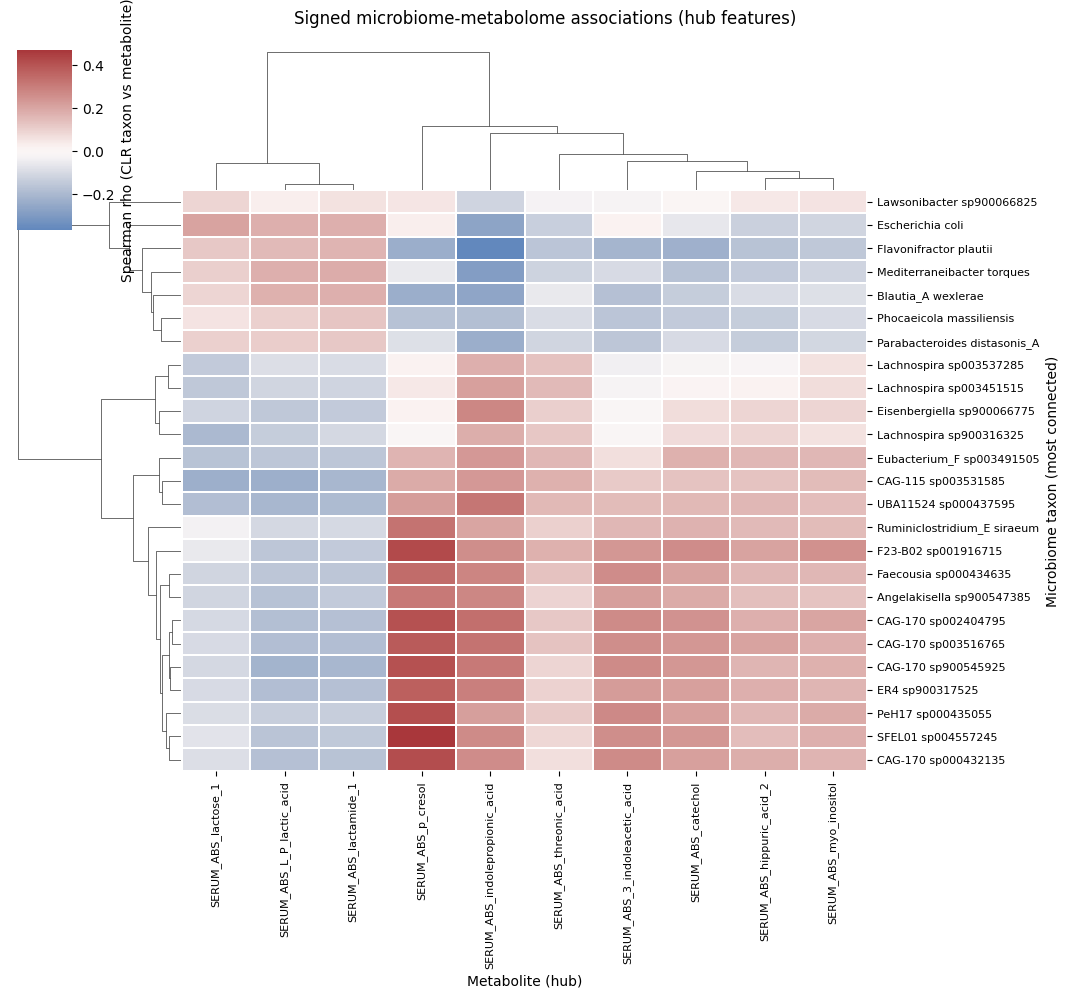

In [8]:
top_metabolites = hub_metab.index.tolist()
top_taxa = (sig.groupby("taxon").size().sort_values(ascending=False).head(25).index.tolist())

focus = rho.loc[top_taxa, top_metabolites]
g = sns.clustermap(
    focus, cmap="vlag", center=0, figsize=(11, 10),
    cbar_kws={"label": "Spearman rho (CLR taxon vs metabolite)"},
    linewidths=0.3, linecolor="white",
)
g.ax_heatmap.set_xlabel("Metabolite (hub)")
g.ax_heatmap.set_ylabel("Microbiome taxon (most connected)")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8)
g.figure.suptitle("Signed microbiome-metabolome associations (hub features)", y=1.02)
plt.show()

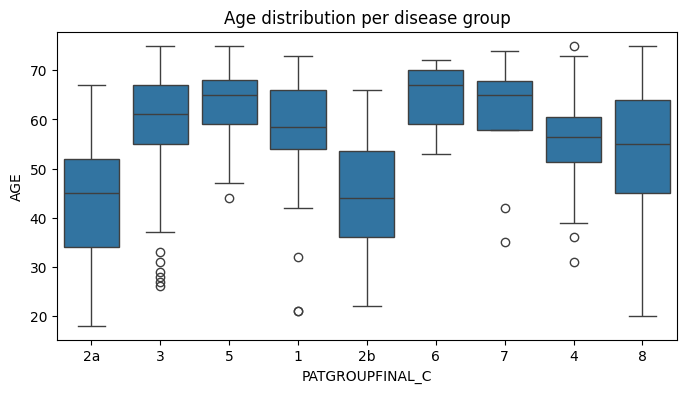

Samples with complete age & gender: 757 / 1042


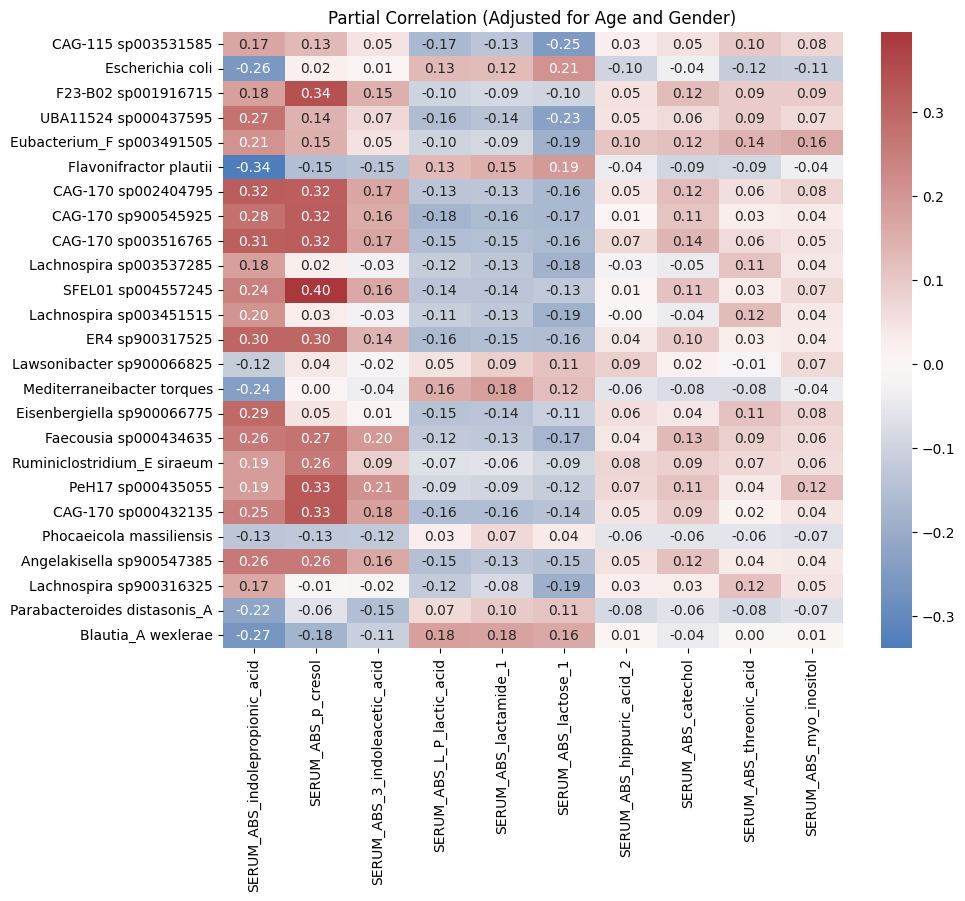

In [11]:
# --- Section 3: Confounding factors analysis ---
import statsmodels.api as sm

# Load metadata (SampleID is the unnamed first column, like the microbiome/metabolome tables)
meta = pd.read_csv("train/metadata.csv").rename(
    columns={"Unnamed: 0": "SampleID"}).set_index("SampleID")
# Align to the same samples / order used by micro_clr and metab_scaled
meta = meta.reindex(micro_clr.index)

# GENDER is already coded 0/1; only label-encode if it comes in as text
if meta['GENDER'].dtype == 'object':
    meta['GENDER'] = meta['GENDER'].astype('category').cat.codes

# Bias check: age distribution across disease groups
plt.figure(figsize=(8, 4))
sns.boxplot(data=meta, x='PATGROUPFINAL_C', y='AGE')
plt.title("Age distribution per disease group")
plt.show()

# Residualization function to isolate the signal from age/gender
def get_residuals(y, confounders):
    X = sm.add_constant(confounders)
    model = sm.OLS(y, X).fit()
    return model.resid

# Keep only samples with complete confounders (age/gender have missing values)
confounders = meta[['AGE', 'GENDER']].dropna()
valid = confounders.index
print(f"Samples with complete age & gender: {len(valid)} / {len(meta)}")

# Apply to top hubs identified in Section 2.4 (all kept index-aligned on `valid`)
resid_micro = pd.DataFrame(index=valid)
for col in top_taxa:
    resid_micro[col] = get_residuals(micro_clr.loc[valid, col], confounders)

resid_metab = pd.DataFrame(index=valid)
for col in top_metabolites:
    resid_metab[col] = get_residuals(metab_scaled.loc[valid, col], confounders)

# Partial Spearman correlation on the residuals (taxa rows vs metabolite columns)
R_partial, _ = spearmanr(resid_micro, resid_metab)
rho_partial = pd.DataFrame(R_partial[:len(top_taxa), len(top_taxa):],
                           index=top_taxa, columns=top_metabolites)

# Visualize age/gender-adjusted associations
plt.figure(figsize=(10, 8))
sns.heatmap(rho_partial, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Partial Correlation (Adjusted for Age and Gender)")
plt.show()